<a href="https://colab.research.google.com/github/Amoonbhatti/nsfw_demo_projects/blob/main/classficationmodel.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Project Work Flow**

Dataset Collection

Class Label Definition

Train Validation Test Split

Data Cleaning

Image Format Verification

Image Resizing

Data Preprocessing

Data Augmentation

Class Balance Checking

Data Loading Pipeline

Model Architecture Design

Model Compilation

Model Training

Validation Monitoring

Model Evaluation

Test Set Prediction

Accuracy and Loss Analysis

Confusion Matrix Generation

Model Saving

Inference Script Creation

Single Image Prediction

Batch Image Prediction

Results Visualization



In [51]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import zipfile
import torch.optim as optim
import matplotlib.pyplot as plt
import numpy as np

In [40]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [41]:
zip_path = "/content/drive/MyDrive/Colab Notebooks/dataset.zip"
extract_path = "/content/dataset"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Dataset Unzipped Successfully")

Dataset Unzipped Successfully


**Lord dataset**

In [42]:
dataset_path = "/content/dataset/dataset"

train_dir = dataset_path + "/train"
val_dir = dataset_path + "/val"
test_dir = dataset_path + "/test"

In [43]:
train_dir,val_dir,test_dir

('/content/dataset/dataset/train',
 '/content/dataset/dataset/val',
 '/content/dataset/dataset/test')

**Image resize**

In [44]:
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor()
])

train_data = datasets.ImageFolder(train_dir, transform=train_transform)
print(train_data.classes)
print(train_data.class_to_idx)
print("Total train images:", len(train_data))

['Natural', 'nude']
{'Natural': 0, 'nude': 1}
Total train images: 6253


**Data Lorder**

In [45]:
train_loader = DataLoader(train_data, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dir, batch_size=32, shuffle=False)
test_loader = DataLoader(test_dir, batch_size=32, shuffle=False)

**Visulize raw data**

In [53]:
dataiter = iter(train_loader)
images, labels = next(dataiter)

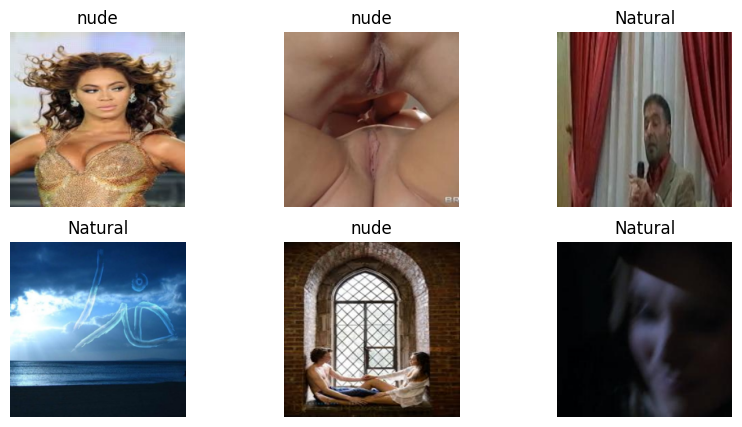

In [54]:
fig = plt.figure(figsize=(10,5))

for i in range(6):

    ax = fig.add_subplot(2,3,i+1)

    img = images[i].permute(1,2,0)   # tensor → image format

    ax.imshow(img)

    ax.set_title(train_data.classes[labels[i]])

    ax.axis("off")

plt.show()

**CNN Model**

In [46]:
import torch
import torch.nn as nn

class CNNmodel(nn.Module):
    def __init__(self):
        super(CNNmodel, self).__init__()

        self.conv = nn.Sequential(
            nn.Conv2d(3,16,3,padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(16,32,3,padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32,64,3,padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        self.fc = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64*28*28,128),
            nn.ReLU(),
            nn.Linear(128,2)
        )

    def forward(self,x):
        x = self.conv(x)
        x = self.fc(x)
        return x

**Model initialize**

In [47]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = CNNmodel().to(device)

print(model)

CNNmodel(
  (conv): Sequential(
    (0): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU()
    (8): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (fc): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=50176, out_features=128, bias=True)
    (2): ReLU()
    (3): Linear(in_features=128, out_features=2, bias=True)
  )
)


**Loss function aur optimizer**

In [52]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)